# Machine Learning --> Creación de máscaras de agua
## Librerías y directorio

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pickle
import json
from pathlib import Path

# Cambiar al directorio del proyecto
os.chdir(r'D:\proyecto_eutrofizacion')
PROJECT_ROOT = os.getcwd()

# Definir rutas usando os.path
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
METADATA_DIR = os.path.join(DATA_DIR, 'metadata')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
EXTERNAL_DATA = os.path.join(DATA_DIR, 'raw', 'external')
RIVER_DATA = os.path.join(EXTERNAL_DATA, 'river_water_dataset')
INDEX_CSV = os.path.join(METADATA_DIR, 'river_water_index.csv')
MODEL_OUTPUT = os.path.join(MODELS_DIR, 'water_segmenter_rf.pkl')
REPORT_OUTPUT = os.path.join(MODELS_DIR, 'training_report.txt')

# Crear directorios si no existen
os.makedirs(METADATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print(f"✓ Directorio de trabajo: {PROJECT_ROOT}")
print(f"✓ Datos: {RIVER_DATA}")
print(f"✓ Modelos: {MODELS_DIR}")
print()

✓ Directorio de trabajo: D:\proyecto_eutrofizacion
✓ Datos: D:\proyecto_eutrofizacion\data\raw\external\river_water_dataset
✓ Modelos: D:\proyecto_eutrofizacion\models



## Funciones

In [ ]:
def log_print(mensaje, archivo_log=None):
    """Imprime mensaje y opcionalmente lo guarda en archivo."""
    print(mensaje)
    if archivo_log and os.path.isfile(archivo_log):
        with open(archivo_log, 'a', encoding='utf-8') as f:
            f.write(mensaje + '\n')

def cargar_mascara_desde_labelimg(ruta_json, alto_img, ancho_img):
    """
    Carga máscara de segmentación desde JSON (LabelImg).
    Solo utiliza regiones etiquetadas como 'water'.
    
    Parámetros
    ----------
    ruta_json : str
        Ruta al archivo JSON con anotaciones LabelImg.
    alto_img : int
        Alto de la imagen.
    ancho_img : int
        Ancho de la imagen.
    
    Retorna
    -------
    np.ndarray
        Máscara binaria (255=agua, 0=no-agua).
    """
    mascara = np.zeros((alto_img, ancho_img), dtype=np.uint8)
    
    if not os.path.isfile(ruta_json):
        print(f"⚠️  No se encontró: {ruta_json}")
        return mascara
    
    try:
        with open(ruta_json, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except (json.JSONDecodeError, IOError) as e:
        print(f"⚠️  Error al leer {ruta_json}: {e}")
        return mascara
    
    for shape in data.get('shapes', []):
        if shape.get('label', '').lower() == 'water':
            points = np.array(shape['points'], dtype=np.int32)
            if len(points) > 0:
                cv2.fillPoly(mascara, [points], 255)
    
    return mascara

def extraer_features_pixel(imagen_bgr):
    """
    Extrae 6 features por píxel: HSV + Lab + textura local.
    
    Features:
        0: H (Hue) - tono en rango 0-180
        1: S (Saturation) - saturación en rango 0-255
        2: V (Value) - brillo en rango 0-255
        3: a* - componente azul-amarillo del Lab en rango 0-255
        4: b* - componente rojo-verde del Lab en rango 0-255
        5: Textura (desv. est. local en ventana 5x5)
    
    Parámetros
    ----------
    imagen_bgr : np.ndarray
        Imagen BGR cargada con cv2.imread().
    
    Retorna
    -------
    np.ndarray
        Array de forma (n_pixeles, 6) con features normalizados.
    """
    # Convertir espacios de color
    hsv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    
    # Calcular textura local: desviación estándar en ventana 5x5
    # Agua típicamente tiene baja varianza (suave), vegetación alta varianza (rugosa)
    media_local = cv2.blur(gray, (5, 5))
    media_sq_local = cv2.blur(gray**2, (5, 5))
    textura = np.sqrt(np.abs(media_sq_local - media_local**2))
    
    # Apilar features: (H, S, V, a*, b*, textura)
    features = np.stack([
        hsv[:, :, 0],  # H
        hsv[:, :, 1],  # S
        hsv[:, :, 2],  # V
        lab[:, :, 1],  # a*
        lab[:, :, 2],  # b*
        textura        # Textura local
    ], axis=-1)
    
    # Remodelar a (n_pixeles, 6)
    return features.reshape(-1, 6)

# Preparar datos

def indexar_river_water(root_path=None):
    """
    Recorre carpetas de RivAIrSet y genera índice CSV.
    
    Estructura esperada:
        river_water_dataset/
        ├── 2019/
        │   ├── images/
        │   │   ├── DJI_0001.JPG
        │   │   └── ...
        │   └── labels_segmentation/
        │       ├── DJI_0001.json
        │       └── ...
        └── 2020/...
    
    Parámetros
    ----------
    root_path : str, optional
        Ruta a river_water_dataset. Si es None, usa RIVER_DATA.
    
    Retorna
    -------
    pd.DataFrame
        DataFrame con columnas: year, image_id, image_path, label_path, exists
    """
    if root_path is None:
        root_path = RIVER_DATA
    
    if not os.path.isdir(root_path):
        print(f"❌ No existe: {root_path}")
        return pd.DataFrame()
    
    records = []
    
    # Iterar sobre años (carpetas numéricas)
    for year_folder in sorted(os.listdir(root_path)):
        year_path = os.path.join(root_path, year_folder)
        
        if not os.path.isdir(year_path):
            continue
        
        try:
            year = int(year_folder)
        except ValueError:
            continue
        
        images_dir = os.path.join(year_path, 'images')
        labels_dir = os.path.join(year_path, 'labels_segmentation')
        
        if not os.path.isdir(images_dir) or not os.path.isdir(labels_dir):
            print(f"⚠️  Año {year}: falta images/ o labels_segmentation/")
            continue
        
        print(f"Indexando año {year}...")
        
        # Iterar sobre imágenes JPG en ese año
        for img_file in sorted(os.listdir(images_dir)):
            if not img_file.lower().endswith(('.jpg', '.jpeg')):
                continue
            
            image_id = os.path.splitext(img_file)[0]
            image_path = os.path.join(images_dir, img_file)
            
            # Buscar JSON correspondiente
            json_file = f"{image_id}.json"
            label_path = os.path.join(labels_dir, json_file)
            
            # Verificar existencia
            exists = os.path.isfile(image_path) and os.path.isfile(label_path)
            
            records.append({
                'year': year,
                'image_id': image_id,
                'image_path': image_path,
                'label_path': label_path,
                'exists': exists
            })
            
            if not exists:
                print(f"  ⚠️  {image_id}: falta archivo")
    
    # Crear DataFrame y guardar
    df = pd.DataFrame(records)
    df.to_csv(INDEX_CSV, index=False)
    
    print(f"\n✓ Índice guardado: {INDEX_CSV}")
    print(f"  Total: {len(df)} imágenes")
    print(f"  Válidas: {df['exists'].sum()}")
    
    return df

def preparar_dataset_entrenamiento(
    indice_csv=None, 
    n_imagenes=200, 
    muestreo_pixeles=2000,
    downscale=4
):
    """
    Procesa imágenes de RivAIrSet usando el formato de CSV existente.
    Adaptado para columnas: filepath, segmentation_mask_path, etc.
    """
    if indice_csv is None:
        indice_csv = INDEX_CSV
    
    if not os.path.isfile(indice_csv):
        print(f"❌ No existe índice: {indice_csv}")
        return None, None
    
    # Cargar índice
    df = pd.read_csv(indice_csv)
    
    # Verificar que existan las imágenes y máscaras
    # (Convertir backslashes a forward slashes para compatibilidad cross-platform)
    df['filepath'] = df['filepath'].str.replace('\\', '/')
    df['segmentation_mask_path'] = df['segmentation_mask_path'].str.replace('\\', '/')
    
    # Submuestrear imágenes
    n_imagenes = min(n_imagenes, len(df))
    df_sample = df.sample(n=n_imagenes, random_state=42)
    
    print(f"Procesando {len(df_sample)} imágenes...")
    print(f"  Sitios: {df_sample['site'].unique()}")
    print(f"  Años: {df_sample['group'].unique()}")
    print()
    
    X_all, y_all = [], []
    images_procesadas = 0
    
    for idx, row in df_sample.iterrows():
        image_path = row['filepath']
        label_path = row['segmentation_mask_path']
        
        # Verificar que existan
        if not os.path.isfile(image_path):
            print(f"  ⚠️  No existe: {image_path}")
            continue
        if not os.path.isfile(label_path):
            print(f"  ⚠️  No existe máscara: {label_path}")
            continue
        
        # Cargar imagen
        img = cv2.imread(image_path)
        if img is None:
            print(f"  ⚠️  No se pudo leer: {os.path.basename(image_path)}")
            continue
        
        alto_orig, ancho_orig = img.shape[:2]
        
        # Cargar ground truth
        mask_gt = cargar_mascara_desde_labelimg(label_path, alto_orig, ancho_orig)
        
        # Verificar que la máscara tenga píxeles de agua
        if (mask_gt > 0).sum() == 0:
            print(f"  ⚠️  {os.path.basename(image_path)}: máscara vacía (sin agua)")
            continue
        
        # Downscale
        img_small = cv2.resize(
            img, 
            (ancho_orig // downscale, alto_orig // downscale),
            interpolation=cv2.INTER_AREA
        )
        mask_small = cv2.resize(
            mask_gt,
            (ancho_orig // downscale, alto_orig // downscale),
            interpolation=cv2.INTER_NEAREST
        )
        
        # Extraer features
        features = extraer_features_pixel(img_small)
        labels = (mask_small.flatten() > 0).astype(int)
        
        # Submuestrear píxeles: balancea agua vs no-agua
        idx_agua = np.where(labels == 1)[0]
        idx_no_agua = np.where(labels == 0)[0]
        
        n_muestra = min(
            muestreo_pixeles // 2,
            len(idx_agua),
            len(idx_no_agua)
        )
        
        if n_muestra == 0:
            print(f"  ⚠️  {os.path.basename(image_path)}: no hay píxeles balanceados")
            continue
        
        # Seleccionar índices equilibrados
        idx_seleccionados = np.concatenate([
            np.random.choice(idx_agua, n_muestra, replace=False),
            np.random.choice(idx_no_agua, n_muestra, replace=False)
        ])
        
        X_all.append(features[idx_seleccionados])
        y_all.append(labels[idx_seleccionados])
        
        images_procesadas += 1
        if images_procesadas % 20 == 0:
            print(f"  ✓ {images_procesadas} imágenes procesadas...")
    
    if len(X_all) == 0:
        print("❌ No se pudieron procesar imágenes")
        return None, None
    
    # Concatenar todos los features
    X = np.vstack(X_all)
    y = np.concatenate(y_all)
    
    print(f"\n✓ Dataset preparado:")
    print(f"  Imágenes procesadas: {images_procesadas}")
    print(f"  Píxeles totales: {len(X)}")
    print(f"  Agua: {(y == 1).sum()} ({(y == 1).sum()/len(y)*100:.1f}%)")
    print(f"  No-agua: {(y == 0).sum()} ({(y == 0).sum()/len(y)*100:.1f}%)")
    
    return X, y


# Entrenamiento

def entrenar_modelo(X, y, n_estimators=100, max_depth=15):
    """
    Entrena Random Forest para clasificación de agua.
    
    Parámetros
    ----------
    X : np.ndarray
        Features de entrada (n_muestras, 6).
    y : np.ndarray
        Etiquetas binarias (0/1).
    n_estimators : int
        Número de árboles en el bosque.
    max_depth : int
        Profundidad máxima de cada árbol.
    
    Retorna
    -------
    dict
        Diccionario con modelo entrenado y métricas.
    """
    print("Dividiendo datos (80% train, 20% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    
    print(f"  Train: {len(X_train)} ({(y_train == 1).sum()} agua)")
    print(f"  Test: {len(X_test)} ({(y_test == 1).sum()} agua)")
    
    print("\nEntrenando Random Forest...")
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    clf.fit(X_train, y_train)
    print("✓ Entrenamiento completado")
    
    # Predicciones
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    
    # Métricas
    f1_train = f1_score(y_train, y_pred_train)
    f1_test = f1_score(y_test, y_pred_test)
    
    print(f"\n✓ Modelo entrenado:")
    print(f"  Train F1: {f1_train:.4f}")
    print(f"  Test F1: {f1_test:.4f}")
    
    print("\nReporte de clasificación (Test set):")
    print(classification_report(y_test, y_pred_test, target_names=['no_agua', 'agua']))
    
    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred_test)
    print("\nMatriz de confusión (Test):")
    print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
    print(f"  FN={cm[1,0]}, TP={cm[1,1]}")
    
    # Feature importance
    print("\nImportancia de features:")
    feature_names = ['H (Hue)', 'S (Sat)', 'V (Brillo)', 'a* (Lab)', 'b* (Lab)', 'Textura']
    for name, imp in zip(feature_names, clf.feature_importances_):
        print(f"  {name:15s}: {imp:.4f} ({imp*100:.1f}%)")
    
    return {
        'modelo': clf,
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'y_pred_test': y_pred_test,
        'f1_train': f1_train,
        'f1_test': f1_test,
        'feature_importances': clf.feature_importances_,
        'confusion_matrix': cm
    }

def guardar_modelo(resultado, output_path=None, report_path=None):
    """
    Guarda modelo entrenado y reporte.
    
    Parámetros
    ----------
    resultado : dict
        Diccionario retornado por entrenar_modelo().
    output_path : str, optional
        Ruta del modelo pickle. Si es None, usa MODEL_OUTPUT.
    report_path : str, optional
        Ruta del reporte. Si es None, usa REPORT_OUTPUT.
    """
    if output_path is None:
        output_path = MODEL_OUTPUT
    if report_path is None:
        report_path = REPORT_OUTPUT
    
    # Guardar modelo
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    with open(output_path, 'wb') as f:
        pickle.dump(resultado['modelo'], f)
    print(f"✓ Modelo guardado: {output_path}")
    
    # Guardar reporte
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 60 + "\n")
        f.write("REPORTE DE ENTRENAMIENTO - SEGMENTADOR DE AGUA\n")
        f.write("=" * 60 + "\n\n")
        
        f.write("MÉTRICAS\n")
        f.write("-" * 60 + "\n")
        f.write(f"F1-Score (Train): {resultado['f1_train']:.4f}\n")
        f.write(f"F1-Score (Test): {resultado['f1_test']:.4f}\n\n")
        
        f.write("MATRIZ DE CONFUSIÓN (Test)\n")
        f.write("-" * 60 + "\n")
        cm = resultado['confusion_matrix']
        f.write(f"TN (agua detectada correctamente): {cm[0,0]}\n")
        f.write(f"FP (falsos positivos): {cm[0,1]}\n")
        f.write(f"FN (falsos negativos): {cm[1,0]}\n")
        f.write(f"TP (agua no-agua detectada correctamente): {cm[1,1]}\n\n")
        
        f.write("IMPORTANCIA DE FEATURES\n")
        f.write("-" * 60 + "\n")
        feature_names = ['H (Hue)', 'S (Sat)', 'V (Brillo)', 'a* (Lab)', 'b* (Lab)', 'Textura']
        for name, imp in zip(feature_names, resultado['feature_importances']):
            f.write(f"{name:15s}: {imp:.4f} ({imp*100:.1f}%)\n")
        
        f.write("\n" + "=" * 60 + "\n")
        f.write("Modelo listo para usar: segmentar_agua_supervisado()\n")
        f.write("=" * 60 + "\n")
    
    print(f"✓ Reporte guardado: {report_path}")


## Main -- Entrenamiento

In [13]:
if __name__ == '__main__':
    print("=" * 70)
    print("Entrenamiento Random Forest")
    print("=" * 70)
    print()
    
    # PASO 1: Indexar RivAIrSet
    print("PASO 1: Indexando RivAIrSet...")
    print("-" * 70)
    if not os.path.isfile(INDEX_CSV):
        df_index = indexar_river_water()
    else:
        print(f"✓ Índice ya existe: {INDEX_CSV}")
        df_index = pd.read_csv(INDEX_CSV)
    print()
    
    # PASO 2: Preparar dataset
    print("PASO 2: Preparando dataset de entrenamiento...")
    print("-" * 70)
    X, y = preparar_dataset_entrenamiento(
        indice_csv=INDEX_CSV,
        n_imagenes=1000,
        muestreo_pixeles=2000,
        downscale=4
    )
    
    if X is None or y is None:
        print("❌ Error en preparación de datos. Abortando.")
        exit(1)
    print()
    
    # PASO 3: Entrenar modelo
    print("PASO 3: Entrenando modelo...")
    print("-" * 70)
    resultado = entrenar_modelo(X, y, n_estimators=100, max_depth=15)
    print()
    
    # PASO 4: Guardar artefactos
    print("PASO 4: Guardando artefactos...")
    print("-" * 70)
    guardar_modelo(resultado)
    print()

    print("✓ ENTRENAMIENTO COMPLETADO")
    print(f"\nModelo guardado en: {MODEL_OUTPUT}")
    print(f"Reporte en: {REPORT_OUTPUT}")

Entrenamiento Random Forest

PASO 1: Indexando RivAIrSet...
----------------------------------------------------------------------
✓ Índice ya existe: D:\proyecto_eutrofizacion\data\metadata\river_water_index.csv

PASO 2: Preparando dataset de entrenamiento...
----------------------------------------------------------------------
Procesando 1000 imágenes...
  Sitios: <StringArray>
['basento_river']
Length: 1, dtype: str
  Años: [2019 2021 2020 2022 2023 2024]

  ✓ 20 imágenes procesadas...
  ✓ 40 imágenes procesadas...
  ✓ 60 imágenes procesadas...
  ✓ 80 imágenes procesadas...
  ✓ 100 imágenes procesadas...
  ✓ 120 imágenes procesadas...
  ⚠️  DJI_9170.JPG: máscara vacía (sin agua)
  ✓ 140 imágenes procesadas...
  ✓ 160 imágenes procesadas...
  ✓ 180 imágenes procesadas...
  ✓ 200 imágenes procesadas...
  ✓ 220 imágenes procesadas...
  ✓ 240 imágenes procesadas...
  ✓ 260 imágenes procesadas...
  ✓ 280 imágenes procesadas...
  ✓ 300 imágenes procesadas...
  ✓ 320 imágenes procesadas..

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   55.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.7min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


✓ Entrenamiento completado


[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    5.4s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:   14.8s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    2.7s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    6.2s finished



✓ Modelo entrenado:
  Train F1: 0.8716
  Test F1: 0.8603

Reporte de clasificación (Test set):
              precision    recall  f1-score   support

     no_agua       0.84      0.90      0.87    199540
        agua       0.89      0.83      0.86    199540

    accuracy                           0.87    399080
   macro avg       0.87      0.87      0.86    399080
weighted avg       0.87      0.87      0.86    399080


Matriz de confusión (Test):
  TN=179414, FP=20126
  FN=33737, TP=165803

Importancia de features:
  H (Hue)        : 0.1166 (11.7%)
  S (Sat)        : 0.0567 (5.7%)
  V (Brillo)     : 0.0827 (8.3%)
  a* (Lab)       : 0.1735 (17.4%)
  b* (Lab)       : 0.0470 (4.7%)
  Textura        : 0.5236 (52.4%)

PASO 4: Guardando artefactos...
----------------------------------------------------------------------
✓ Modelo guardado: D:\proyecto_eutrofizacion\models\water_segmenter_rf.pkl
✓ Reporte guardado: D:\proyecto_eutrofizacion\models\training_report.txt

✓ ENTRENAMIENTO COMPLETA

# Probar modelo entrenado con imagenes a elección

In [15]:
import matplotlib.pyplot as plt

def segmentar_agua_supervisado(ruta_imagen, ruta_modelo=None, downscale=4):
    """
    Carga una imagen, extrae las mismas features usadas durante
    el entrenamiento y genera una máscara de agua con Random Forest.
    """

    if ruta_modelo is None:
        ruta_modelo = MODEL_OUTPUT

    # -----------------------------
    # 1. Cargar modelo
    # -----------------------------
    with open(ruta_modelo, 'rb') as f:
        modelo = pickle.load(f)

    # -----------------------------
    # 2. Cargar imagen
    # -----------------------------
    imagen = cv2.imread(ruta_imagen)

    if imagen is None:
        raise FileNotFoundError(f"No se pudo cargar: {ruta_imagen}")

    alto_orig, ancho_orig = imagen.shape[:2]

    # -----------------------------
    # 3. Reducir imagen
    # -----------------------------
    ancho_small = ancho_orig // downscale
    alto_small = alto_orig // downscale

    imagen_small = cv2.resize(
        imagen,
        (ancho_small, alto_small),
        interpolation=cv2.INTER_AREA
    )

    # -----------------------------
    # 4. Extraer features
    # -----------------------------
    features = extraer_features_pixel(imagen_small)

    # -----------------------------
    # 5. Predecir cada píxel
    # -----------------------------
    prediccion = modelo.predict(features)

    # -----------------------------
    # 6. Convertir a máscara
    # -----------------------------
    mascara_small = (prediccion.reshape(
        alto_small,
        ancho_small
    ) * 255).astype(np.uint8)

    # -----------------------------
    # 7. Volver al tamaño original
    # -----------------------------
    mascara = cv2.resize(
        mascara_small,
        (ancho_orig, alto_orig),
        interpolation=cv2.INTER_NEAREST
    )

    return imagen, mascara


def visualizar_segmentacion(nombre_imagen, downscale=4):

    # Cargar índice
    df = pd.read_csv(INDEX_CSV)

    # Buscar la imagen por nombre dentro de filepath
    filas = df[df['filepath'].str.contains(
        nombre_imagen,
        case=False,
        na=False
    )]

    if len(filas) == 0:
        raise ValueError(
            f"No se encontró la imagen '{nombre_imagen}' en el índice."
        )

    fila = filas.iloc[0]

    ruta_imagen = fila['filepath']
    ruta_gt = fila['segmentation_mask_path']

    print("Imagen:")
    print(ruta_imagen)

    print("\nGround Truth:")
    print(ruta_gt)

    # ---------------------------------
    # Predicción
    # ---------------------------------

    imagen, mascara_pred = segmentar_agua_supervisado(
        ruta_imagen,
        downscale=downscale
    )

    # ---------------------------------
    # Ground Truth
    # ---------------------------------

    alto, ancho = imagen.shape[:2]

    mask_gt = cargar_mascara_desde_labelimg(
        ruta_gt,
        alto,
        ancho
    )

    # ---------------------------------
    # Visualización
    # ---------------------------------

    plt.figure(figsize=(18, 6))

    # Imagen original
    plt.subplot(1, 3, 1)

    plt.imshow(
        cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    )

    plt.title("Imagen original")
    plt.axis("off")

    # Ground Truth
    plt.subplot(1, 3, 2)

    plt.imshow(
        mask_gt,
        cmap="gray"
    )

    plt.title("Ground Truth")
    plt.axis("off")

    # Predicción
    plt.subplot(1, 3, 3)

    plt.imshow(
        mascara_pred,
        cmap="gray"
    )

    plt.title("Predicción Random Forest")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Imagen:
data/raw/external/river_water_dataset\2019\images\DJI_146.JPG

Ground Truth:
data/raw/external/river_water_dataset\2019\labels_segmentation\DJI_146.json


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    1.2s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    4.7s finished


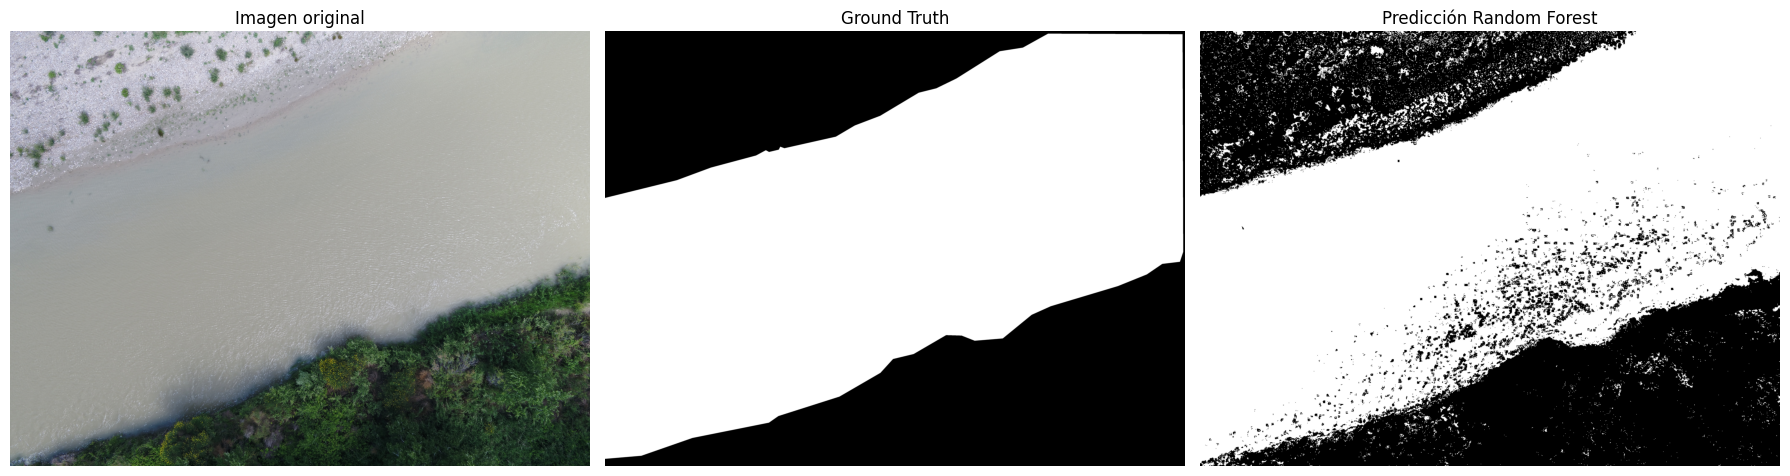

In [17]:
visualizar_segmentacion("DJI_146")